<a href="https://colab.research.google.com/github/tjdux/basic_of_ml/blob/main/31_%ED%85%90%EC%84%9C%ED%94%8C%EB%A1%9C_%ED%97%88%EB%B8%8C%EB%A1%9C_%EA%B0%95%EC%95%84%EC%A7%80_%EC%82%AC%EC%A7%84_%EB%B6%84%EB%A5%98%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 텐서플로 허브로 강아지 사진 분류하기

In [1]:
import tf_keras as keras
from tf_keras import layers
import tensorflow_hub as hub

In [2]:
hub_efficientb0 = keras.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1.0 / 255.0),
    hub.KerasLayer("https://www.kaggle.com/models/tensorflow/efficientnet/TensorFlow2/b0-classification/1")
])

In [3]:
!gdown 1xGkTT3uwYt4myj6eJJeYtdEFgTi2Sj8C
!unzip cat-dog-images.zip

Downloading...
From: https://drive.google.com/uc?id=1xGkTT3uwYt4myj6eJJeYtdEFgTi2Sj8C
To: /content/cat-dog-images.zip
100% 182k/182k [00:00<00:00, 60.4MB/s]
Archive:  cat-dog-images.zip
   creating: images/
  inflating: images/dog.png          
  inflating: images/cat.png          


In [4]:
import numpy as np
from PIL import Image

dog_png = np.array(Image.open('images/dog.png'))

In [5]:
from keras.applications import efficientnet

predictions = hub_efficientb0.predict(dog_png[np.newaxis, :])
efficientnet.decode_predictions(predictions)

1/1 [==============================] - 4s 4s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


[[('n02099712', 'Labrador_retriever', np.float32(0.3682942)),
  ('n02104029', 'kuvasz', np.float32(0.19339868)),
  ('n02099601', 'golden_retriever', np.float32(0.061458193)),
  ('n02111500', 'Great_Pyrenees', np.float32(0.05779694)),
  ('n02095889', 'Sealyham_terrier', np.float32(0.017902788))]]

## 허깅페이스로 강아지 사진 분류하기

In [6]:
from transformers import pipeline

In [7]:
pipe = pipeline(task='image-classification', device=0,
                model='google/efficientnet-b0')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/360 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

The image processor of type `EfficientNetImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [8]:
pipe('images/dog.png')

[{'label': 'Labrador retriever', 'score': 0.36829379200935364},
 {'label': 'kuvasz', 'score': 0.1933988481760025},
 {'label': 'golden retriever', 'score': 0.06145830079913139},
 {'label': 'Great Pyrenees', 'score': 0.057797037065029144},
 {'label': 'Sealyham terrier, Sealyham', 'score': 0.01790277287364006}]

## 전이 학습으로 피스타치오 품종 분류하기
- 전이 학습 (transfer learning): 사전 훈련된 신경망의 대부분은 그대로 두고 최상층 일부 층만 다시 훈련하여 새로운 문제에 적응시키는 방법

### 사전 훈련된 모델로 피스타치오 품종 분류하기

In [9]:
!gdown 10bnEC6-ZfXZFZ2mb3zoWd38TjYufanWo
!unzip -q Pistachio_Image_Dataset.zip

Downloading...
From: https://drive.google.com/uc?id=10bnEC6-ZfXZFZ2mb3zoWd38TjYufanWo
To: /content/Pistachio_Image_Dataset.zip
100% 25.9M/25.9M [00:00<00:00, 40.8MB/s]


In [10]:
pistachio_sample = np.array(Image.open(
    'Pistachio_Image_Dataset/Kirmizi_Pistachio/kirmizi (1).jpg'
))
pistachio_sample.shape

(600, 600, 3)

In [11]:
efficientb7 = keras.applications.EfficientNetB7()
predictions = efficientb7.predict(pistachio_sample[np.newaxis, :])
efficientnet.decode_predictions(predictions)

1/1 [==============================] - 13s 13s/step


[[('n01950731', 'sea_slug', np.float32(0.23482426)),
  ('n01924916', 'flatworm', np.float32(0.20674418)),
  ('n01943899', 'conch', np.float32(0.086223386)),
  ('n01945685', 'slug', np.float32(0.085005425)),
  ('n01955084', 'chiton', np.float32(0.02824294))]]

### 전이 학습으로 피스타치오 품종 분류하기

In [12]:
keras_efficientb0_base = keras.applications.EfficientNetB0(
    include_top=False
)
feature_map = keras_efficientb0_base(pistachio_sample[np.newaxis, :])
feature_map.shape

16705208/16705208 [==============================] - 0s 0us/step


TensorShape([1, 18, 18, 1280])

In [13]:
train_ds, val_ds = keras.utils.image_dataset_from_directory(
    'Pistachio_Image_Dataset', image_size=(224, 224), batch_size=16,
    validation_split=0.2, subset='both', seed=42
)

Found 2148 files belonging to 2 classes.
Using 1719 files for training.
Using 429 files for validation.


In [14]:
keras_efficientb0_base.trainable = False

In [15]:
inputs = keras.Input(shape=(224, 224, 3))
x = keras_efficientb0_base(inputs)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model = keras.Model(inputs, outputs)

In [16]:
rmsprop = keras.optimizers.RMSprop(learning_rate=5e-5)
model.compile(optimizer=rmsprop, loss='binary_crossentropy',
              metrics=['accuracy'])
hist = model.fit(train_ds, epochs=20, validation_data=val_ds)

Epoch 1/20
108/108 [==============================] - 23s 137ms/step - loss: 0.4868 - accuracy: 0.8104 - val_loss: 0.3338 - val_accuracy: 0.9114
Epoch 2/20
108/108 [==============================] - 6s 53ms/step - loss: 0.2951 - accuracy: 0.9168 - val_loss: 0.2274 - val_accuracy: 0.9347
Epoch 3/20
108/108 [==============================] - 5s 46ms/step - loss: 0.2149 - accuracy: 0.9412 - val_loss: 0.1773 - val_accuracy: 0.9510
Epoch 4/20
108/108 [==============================] - 5s 49ms/step - loss: 0.1700 - accuracy: 0.9494 - val_loss: 0.1508 - val_accuracy: 0.9464
Epoch 5/20
108/108 [==============================] - 5s 45ms/step - loss: 0.1426 - accuracy: 0.9599 - val_loss: 0.1291 - val_accuracy: 0.9627
Epoch 6/20
108/108 [==============================] - 6s 53ms/step - loss: 0.1260 - accuracy: 0.9604 - val_loss: 0.1146 - val_accuracy: 0.9650
Epoch 7/20
108/108 [==============================] - 6s 53ms/step - loss: 0.1107 - accuracy: 0.9663 - val_loss: 0.1074 - val_accuracy: 0.97

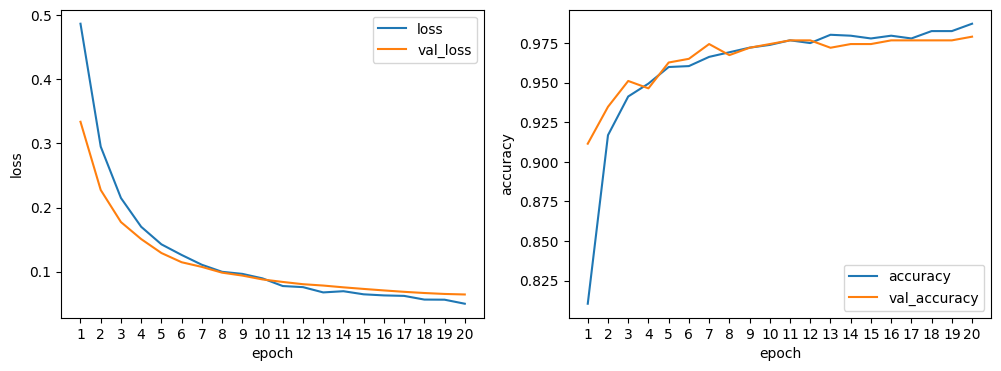

In [17]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(range(1, 21), hist.history['loss'], label='loss')
axs[0].plot(range(1, 21), hist.history['val_loss'], label='val_loss')
axs[0].set_xticks(range(1, 21))
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(range(1, 21), hist.history['accuracy'], label='accuracy')
axs[1].plot(range(1, 21), hist.history['val_accuracy'], label='val_accuracy')
axs[1].set_xticks(range(1, 21))
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].legend()

plt.show()